# Sklearn 2 — Regression
Predicting continuous values — prices, scores, temperatures*

## What is Regression?
Regression predicts a **continuous numerical value** — unlike classification, which predicts a category.

**Input:** features (independent variables)
**Output:** a continuous number (dependent variable)

| Model | Regularization | Best For |
|-------|---------------|----------|
| Linear Regression | None | Simple baseline, interpretable |
| Ridge | L2 — squared penalty | Correlated features, prevents large weights |
| Lasso | L1 — absolute penalty | Automatic feature selection |

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')
print("Imports done")

Imports done


## 1. Load Dataset — California Housing
Data from the **1990 US Census**. Each row is a census block group (~1,000–3,000 people).

**Target:** `MedHouseVal` — median house value in $100,000 units

| Feature | Description |
|---------|-------------|
| MedInc | Median income of the block (in $10,000s) |
| HouseAge | Median age of houses in the block |
| AveRooms | Average number of rooms per household |
| AveBedrms | Average number of bedrooms per household |
| Population | Total block group population |
| AveOccup | Average number of people per household |
| Latitude | Geographic latitude of the block |
| Longitude | Geographic longitude of the block |

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame
df['MedHouseVal'] = data.target  # target: median house value (in $100k)

print("Shape:", df.shape)
print()
print("Features:", list(data.feature_names))
print()
df.describe().round(2)

Shape: (20640, 9)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


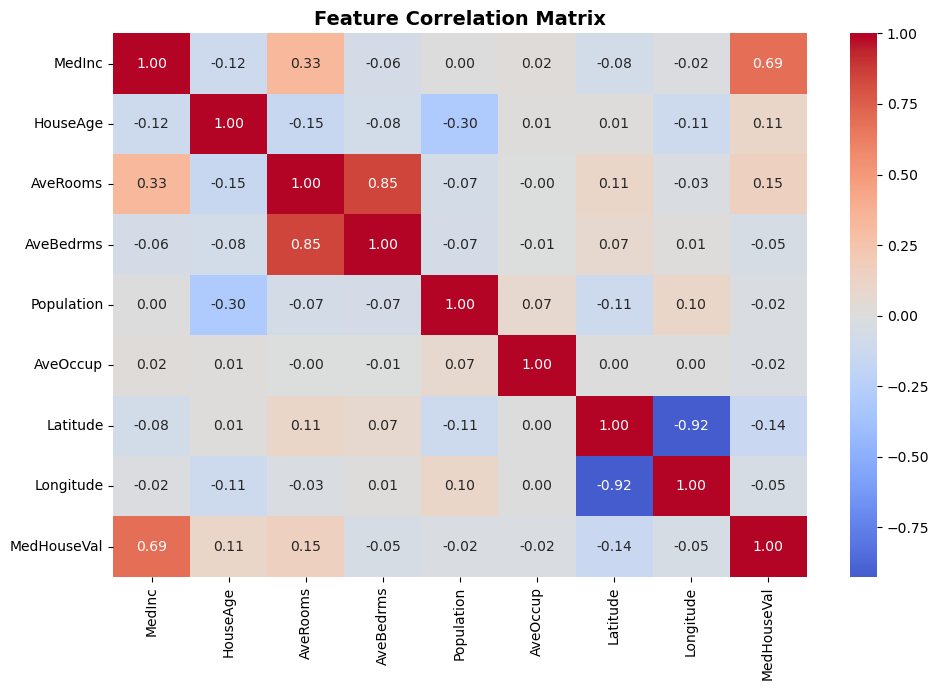

In [3]:
# Correlation heatmap — find what relates to target
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (16512, 8), Test: (4128, 8)


## 2. Linear Regression
Fits the best straight line (or hyperplane in higher dimensions) through the data by minimizing squared errors.

**Math:** `ŷ = w₁x₁ + w₂x₂ + ... + wₙxₙ + b`

- **w** (weights / coefficients) — how much each feature contributes to the prediction
- **b** (bias / intercept) — baseline prediction when all features are 0
- **Objective:** minimize MSE = (1/n) Σ(yᵢ − ŷᵢ)²

**Assumptions:**
- Linear relationship between features and target
- Features are not perfectly correlated (no multicollinearity)
- Errors are approximately normally distributed

**Pros:** Fast, interpretable, strong baseline
**Cons:** Underfits complex non-linear relationships; sensitive to outliers and correlated features

In [5]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)

# Metrics
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=== Linear Regression Results ===")
print(f"  RMSE : {rmse:.4f}  (avg error in $100k units)")
print(f"  MAE  : {mae:.4f}")
print(f"  R²   : {r2:.4f}  (1.0 = perfect, 0 = predicts mean)")

=== Linear Regression Results ===
  RMSE : 0.7456  (avg error in $100k units)
  MAE  : 0.5332
  R²   : 0.5758  (1.0 = perfect, 0 = predicts mean)


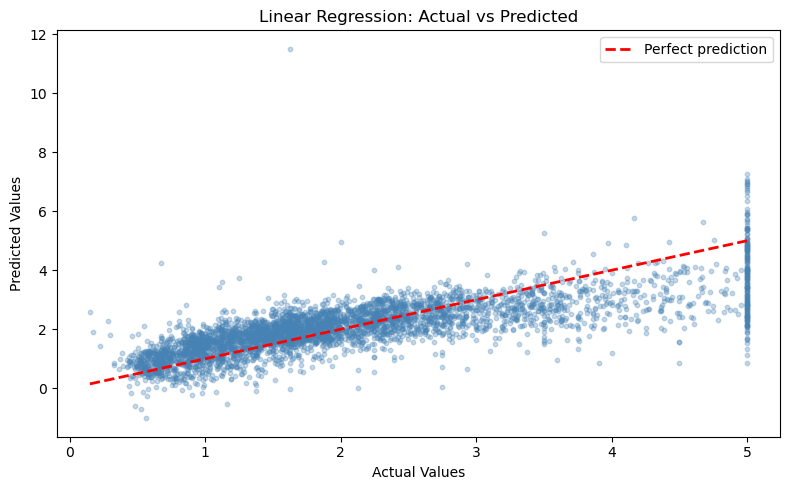

In [6]:
# Visualize predictions vs actual
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect prediction')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()
# Points close to the red line = good predictions

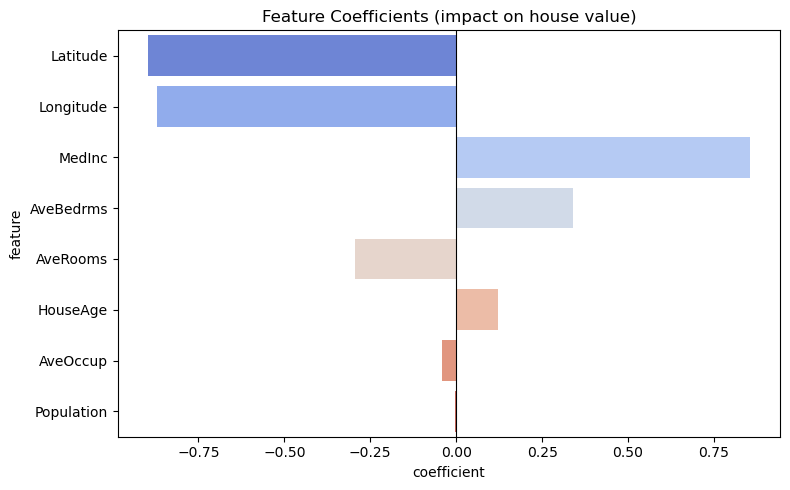

In [7]:
# Feature coefficients — which features matter most?
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': pipe_lr.named_steps['model'].coef_
}).sort_values('coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x='coefficient', y='feature', palette='coolwarm')
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Feature Coefficients (impact on house value)")
plt.tight_layout()
plt.show()

## 3. Ridge Regression (L2 Regularization)
Linear Regression with an added penalty that discourages large coefficients, reducing overfitting.

**Math:** `Loss = MSE + α × Σ(wᵢ²)`

- **α (alpha)** controls regularization strength:
  - α = 0 → identical to Linear Regression
  - Higher α → all coefficients shrink toward 0 (but never reach exactly 0)
- Ridge **distributes** weight reduction across all features — no feature is fully eliminated

**When to use:** When features are correlated with each other, or when the model overfits the training data.

In [8]:
# Try different alpha values (regularization strength)
alphas = [0.01, 0.1, 1, 10, 100]
results = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=alpha))
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    results.append({'alpha': alpha, 'R2': round(r2, 4)})

results_df = pd.DataFrame(results)
print("Ridge — effect of alpha on R²:")
print(results_df.to_string(index=False))
print()
print("Higher alpha = stronger regularization = simpler model")

Ridge — effect of alpha on R²:
 alpha     R2
  0.01 0.5758
  0.10 0.5758
  1.00 0.5758
 10.00 0.5761
100.00 0.5778

Higher alpha = stronger regularization = simpler model


In [9]:
# Best alpha
best_alpha = results_df.loc[results_df['R2'].idxmax(), 'alpha']
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=best_alpha))
])
pipe_ridge.fit(X_train, y_train)
y_pred_r = pipe_ridge.predict(X_test)
print(f"Best Ridge (alpha={best_alpha}) R²: {r2_score(y_test, y_pred_r):.4f}")

Best Ridge (alpha=100.0) R²: 0.5778


## 4. Lasso Regression (L1 Regularization)
Like Ridge, but uses the **absolute value** of weights as the penalty. This crucial difference means Lasso can shrink coefficients **all the way to zero**, removing features entirely.

**Math:** `Loss = MSE + α × Σ|wᵢ|`

- Produces a **sparse model** — many coefficients become exactly 0
- Higher α → more features zeroed out → simpler, more interpretable model
- Acts as built-in **feature selection**

**Ridge vs Lasso:**
| | Ridge (L2) | Lasso (L1) |
|--|-----------|-----------|
| Penalty | Σwᵢ² | Σ\|wᵢ\| |
| Shrinks weights to exactly 0? | No | Yes |
| Feature selection | No | Yes |
| Best when | Many features each have small effects | Few features have strong effects, rest are noise |

**When to use:** When you suspect many features are irrelevant and want the model to ignore them automatically.

In [10]:
pipe_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Lasso(alpha=0.1))
])
pipe_lasso.fit(X_train, y_train)
y_pred_l = pipe_lasso.predict(X_test)

coef_lasso = pipe_lasso.named_steps['model'].coef_
zeroed = np.sum(coef_lasso == 0)

print(f"Lasso R²: {r2_score(y_test, y_pred_l):.4f}")
print(f"Features zeroed out by Lasso: {zeroed} / {len(coef_lasso)}")
print()
print("Coefficients:")
for feat, coef in zip(X.columns, coef_lasso):
    status = "  ← REMOVED" if coef == 0 else ""
    print(f"  {feat:20s}: {coef:.4f}{status}")

Lasso R²: 0.4814
Features zeroed out by Lasso: 5 / 8

Coefficients:
  MedInc              : 0.7106
  HouseAge            : 0.1065
  AveRooms            : -0.0000  ← REMOVED
  AveBedrms           : 0.0000  ← REMOVED
  Population          : -0.0000  ← REMOVED
  AveOccup            : -0.0000  ← REMOVED
  Latitude            : -0.0115
  Longitude           : -0.0000  ← REMOVED


## 5. Model Comparison

**Metrics explained:**

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| RMSE | √( mean(y − ŷ)² ) | Average error in the same units as the target — penalizes large errors more heavily |
| MAE | mean(\|y − ŷ\|) | Average absolute error — more robust to outliers than RMSE |
| R² | 1 − SS_res / SS_tot | Proportion of variance explained; 1.0 = perfect, 0 = model just predicts the mean |

Lower RMSE / MAE and higher R² = better model.

In [11]:
models = {
    'Linear Regression': pipe_lr,
    f'Ridge (α={best_alpha})': pipe_ridge,
    'Lasso (α=0.1)': pipe_lasso,
}

print(f"{'Model':<25} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("-" * 52)
for name, pipe in models.items():
    yp = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    mae  = mean_absolute_error(y_test, yp)
    r2   = r2_score(y_test, yp)
    print(f"{name:<25} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}")

Model                         RMSE      MAE       R²
----------------------------------------------------
Linear Regression           0.7456   0.5332   0.5758
Ridge (α=100.0)             0.7438   0.5330   0.5778
Lasso (α=0.1)               0.8244   0.6222   0.4814


## 6. Cross-Validation — Honest Evaluation
A single train/test split can be misleading — you might get lucky (or unlucky) with how the data divides. **K-Fold Cross-Validation** gives a more reliable estimate by testing on every sample exactly once.

**How 5-Fold CV works:**
1. Split data into 5 equal folds
2. Train on 4 folds, test on the held-out fold — repeat 5 times, rotating which fold is held out
3. Average the 5 scores

```
Fold 1: [TEST ] [train] [train] [train] [train]
Fold 2: [train] [TEST ] [train] [train] [train]
Fold 3: [train] [train] [TEST ] [train] [train]
Fold 4: [train] [train] [train] [TEST ] [train]
Fold 5: [train] [train] [train] [train] [TEST ]
```

**Low std** across folds means the model is stable and generalizes well — it isn't just fitting one particular split.

In [12]:
pipe_cv = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])

scores = cross_val_score(pipe_cv, X, y, cv=5, scoring='r2')

print("5-Fold Cross-Validation R² scores:")
for i, s in enumerate(scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean:   {scores.mean():.4f}")
print(f"  Std:    {scores.std():.4f}  ← lower is more stable")

5-Fold Cross-Validation R² scores:
  Fold 1: 0.5487
  Fold 2: 0.4682
  Fold 3: 0.5508
  Fold 4: 0.5370
  Fold 5: 0.6605
  Mean:   0.5530
  Std:    0.0617  ← lower is more stable


## Key Takeaways

- **Linear Regression** — baseline, simple, interpretable. Start here.
- **Ridge** — adds L2 penalty, shrinks weights, good when features correlate
- **Lasso** — adds L1 penalty, zeros out irrelevant features, built-in feature selection
- **R²** — how much variance explained (higher = better, 1.0 = perfect)
- **RMSE** — interpretable error in same units as target
- Always use **cross-validation** for honest performance estimate
- Always use **pipelines** — scaler + model together